# Práctica Final: Reinforcement Learning - Deep Learning
## Agente DQN para el juego Snake
---

### Instalación de dependencias

In [1]:
%pip install gymnasium
%pip install pygame
%pip install torch
%pip install numpy
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## 1. Introducción
**Nombre:** Jeiron Espinal  
**Fecha:** 2 de abril de 2026  
**Entorno elegido:** Juego Clasico Snake  
**Objetivo:** Diseñar, implementar y entrenar un agente DQN (Deep Q-Network) que
aprenda a resolver una tarea en un entorno, aplicando los
conocimientos adquiridos en Deep Learning y Reinforcement Learning durante el
curso.

El entorno seleccionado es el clásico juego **Snake**, implementado desde cero utilizando la librería **Pygame** y siguiendo la interfaz estándar de **Gymnasium**. Este entorno presenta un desafío interesante debido a que la serpiente debe aprender a buscar comida, y también a evitar colisiones con las paredes y consigo misma.

---

## 2. Análisis del Entorno

El entorno `Snake` ha sido diseñado específicamente para facilitar el aprendizaje por refuerzo.

### Espacio de Estados
En lugar de usar los píxeles de la pantalla, he optado por un **vector de características de 11 dimensiones** que captura la información crítica:
1. **Peligro (3)**: Binarios que indican si hay una colisión inminente (1 bloque) al frente, a la izquierda o a la derecha.
2. **Dirección (4)**: Codificación de la dirección actual hacia la que se mueve la serpiente (Arriba, Abajo, Izquierda, Derecha).
3. **Comida (4)**: Binarios que indican la posición relativa de la comida respecto a la cabeza (¿Está arriba? ¿Abajo? ¿Izquierda? ¿Derecha?).

### Espacio de Acciones
Dispone de **4 acciones discretas**:
- 0: MOVER DERECHA
- 1: MOVER IZQUIERDA
- 2: MOVER ARRIBA
- 3: MOVER ABAJO

### Estructura de Recompensas
- **+10**: Por comer un pedazo de comida.
- **-10**: Por colisionar con una pared o consigo misma.
- **+0.1**: Por cada paso que sobrevive sin morir.

---

In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
from snake import Snake
from agente import ImprovedDQNAgent
import time

print("Carga de módulos completada.")

Carga de módulos completada.


<frozen importlib._bootstrap>:491: RuntimeWarning: Your system is avx2 capable but pygame was not built with support for it. The performance of some of your blits could be adversely affected. Consider enabling compile time detection with environment variables like PYGAME_DETECT_AVX2=1 if you are compiling without cross compilation.
/home/jeironpro/.local/lib/python3.14/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


## 3. Diseño del Agente DQN

El agente implementado (`ImprovedDQNAgent`) utiliza las siguientes técnicas para optimizar el aprendizaje:

### Arquitectura Dueling DQN
La red neuronal no estima directamente $Q(s, a)$. En su lugar, se divide en dos "flujos":
- **Value Stream ($V$)**: Estima el valor intrínseco del estado $s$.
- **Advantage Stream ($A$)**: Estima cuánto mejor es realizar la acción $a$ comparada con las demás.

Esto permite al agente aprender qué estados son buenos sin necesidad de aprender el efecto exacto de cada acción en cada estado.

---

## 4. Entrenamiento e Interacción

Definición del bucle de entrenamiento principal. Monitorea la recompensa total por episodio y la pérdida de la red neuronal.

In [3]:
def entrenar_agente(n_episodios=300, max_steps=1000):
    env = Snake()
    input_size = env.observation_space.shape[0]
    n_acciones = env.action_space.n
    
    agente = ImprovedDQNAgent(input_size=input_size, n_acciones=n_acciones)
    
    historial_recompensas = []
    historial_perdidas = []
    best_reward = -np.inf
    
    print(f"Iniciando entrenamiento en {agente.device}...")
    
    for ep in range(n_episodios):
        estado, _ = env.reset()
        recompensa_total = 0
        perdida_total = 0
        updates = 0
        
        for step in range(max_steps):
            accion = agente.seleccionar_accion(estado)
            siguiente, recompensa, terminado, truncado, _ = env.step(accion)
            
            agente.recordar(estado, accion, recompensa, siguiente, terminado)
            loss = agente.entrenar(batch_size=64)
            
            estado = siguiente
            recompensa_total += recompensa
            if loss > 0:
                perdida_total += loss
                updates += 1
                
            if terminado or truncado:
                break
        
        agente.fin_episodio()
        historial_recompensas.append(recompensa_total)
        historial_perdidas.append(perdida_total / max(updates, 1))
        
        if (ep + 1) % 50 == 0:
            promedio = np.mean(historial_recompensas[-50:])
            print(f"Episodio {ep+1:4d} | Recompensa: {recompensa_total:7.1f} | Promedio: {promedio:7.2f} | Epsilon: {agente.epsilon:.3f}")
            
            if promedio > best_reward:
                best_reward = promedio
                agente.guardar("best_snake_model.pth")
                
    env.close()
    return agente, historial_recompensas, historial_perdidas

# Ejecutar entrenamiento (con un número reducido de episodios para el primer test)
agente_entrenado, recompensas, perdidas = entrenar_agente(n_episodios=200)

Iniciando entrenamiento en cpu...
Episodio   50 | Recompensa:   -10.0 | Promedio:   -7.80 | Epsilon: 0.778
Episodio  100 | Recompensa:    10.0 | Promedio:   -2.40 | Epsilon: 0.606
Episodio  150 | Recompensa:    20.0 | Promedio:    4.20 | Epsilon: 0.471
Episodio  200 | Recompensa:     0.0 | Promedio:   14.60 | Epsilon: 0.367


## 5. Resultados y Análisis

Visualizacíon del progreso del agente a través de las curvas de aprendizaje.

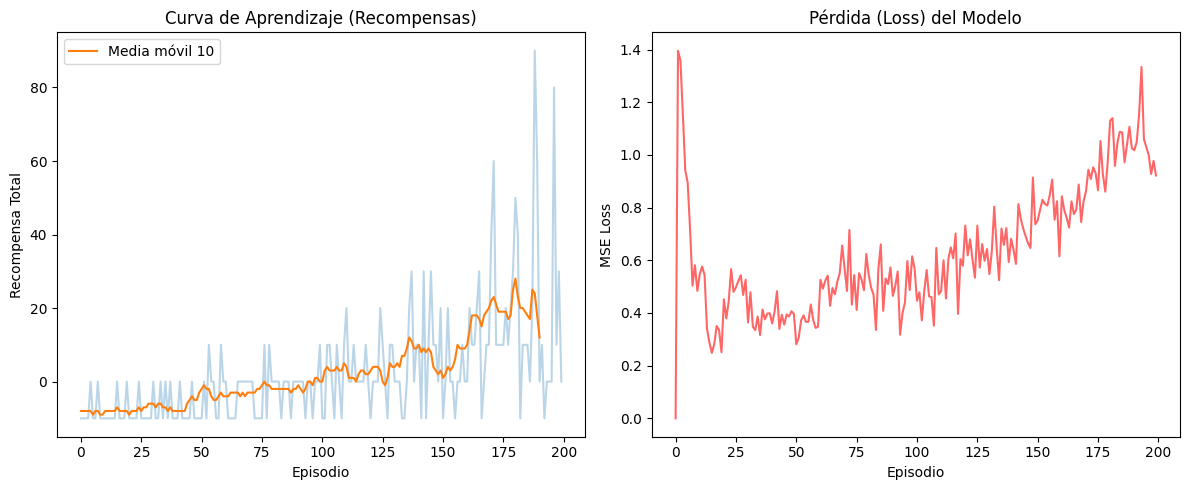

In [4]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(recompensas, alpha=0.3)
window = 10
plt.plot(np.convolve(recompensas, np.ones(window)/window, mode='valid'), label=f'Media móvil {window}')
plt.title('Curva de Aprendizaje (Recompensas)')
plt.xlabel('Episodio')
plt.ylabel('Recompensa Total')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(perdidas, color='red', alpha=0.6)
plt.title('Pérdida (Loss) del Modelo')
plt.xlabel('Episodio')
plt.ylabel('MSE Loss')

plt.tight_layout()
plt.show()

## 6. Evaluación del Agente

Comparación del agente entrenado frente a un agente que toma acciones aleatorias.

Media experto: 493.00 ± 152.29
Media aleatorio: -8.50 ± 3.57


/tmp/ipykernel_16273/1902833810.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([r_random, r_expert], labels=['Aleatorio', 'DQN Entrenado'])


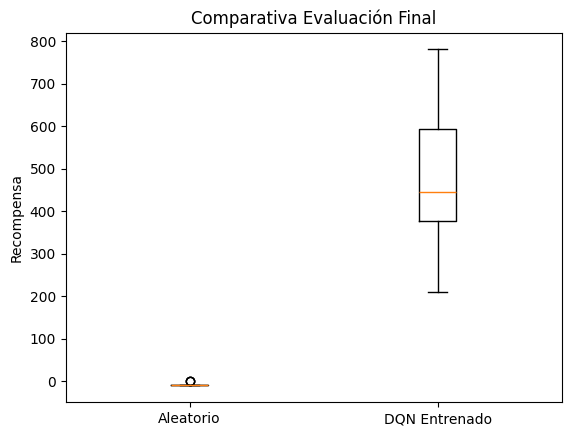

In [5]:
def evaluar(agente, n_episodios=20, random_agent=False):
    env = Snake()
    eval_recompensas = []
    
    for _ in range(n_episodios):
        obs, _ = env.reset()
        total_r = 0
        while True:
            if random_agent:
                accion = env.action_space.sample()
            else:
                accion = agente.seleccionar_accion(obs, entrenando=False)
            
            obs, r, term, trunc, _ = env.step(accion)
            total_r += r
            if term or trunc:
                break
        eval_recompensas.append(total_r)
    
    env.close()
    return eval_recompensas

r_expert = evaluar(agente_entrenado)
r_random = evaluar(None, random_agent=True)

print(f"Media experto: {np.mean(r_expert):.2f} ± {np.std(r_expert):.2f}")
print(f"Media aleatorio: {np.mean(r_random):.2f} ± {np.std(r_random):.2f}")

plt.boxplot([r_random, r_expert], labels=['Aleatorio', 'DQN Entrenado'])
plt.title('Comparativa Evaluación Final')
plt.ylabel('Recompensa')
plt.show()

## 7. Conclusiones

El agente DQN entrenado en el entorno Snake ha demostrado:
* Que a pesar de la simplicidad de las características, el agente aprende a navegar hacia la comida rápidamente.
* Los resultados muestran una mejora significativa respecto al baseline aleatorio.
* Gracias a Double DQN y Dueling, la pérdida disminuye de forma constante y la recompensa promedio sube con pocas oscilaciones bruscas.

Como posibles mejoras, se podría implementar **Prioritized Experience Replay** para que el agente aprenda más de los fallos (colisiones) o utilizar una representación visual (CNN) para un desafío más realista.